<a href="https://colab.research.google.com/github/kesavan6442/Enery-Consumption/blob/main/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Decision Tree
MAE: 40.80060805675196
R2: 0.1632796181636953


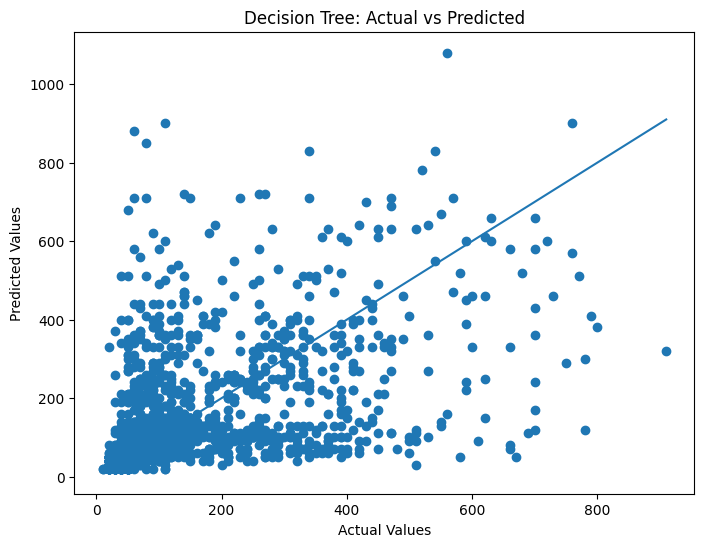

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Load dataset
data = pd.read_csv("energydata_complete.csv")

# Keep only numeric values
data = data.select_dtypes(include=['number']).dropna()

# Split features & target
X = data.drop("Appliances", axis=1)
y = data["Appliances"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = DecisionTreeRegressor()
model.fit(X_train, y_train)

# Prediction
pred = model.predict(X_test)

# Metrics
print("Decision Tree")
print("MAE:", mean_absolute_error(y_test, pred))
print("R2:", r2_score(y_test, pred))

# -------- GRAPH --------

plt.figure(figsize=(8,6))

# Actual vs Predicted scatter plot
plt.scatter(y_test, pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Decision Tree: Actual vs Predicted")

# Diagonal line (perfect prediction line)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()

Linear Regression
MAE: 54.507228906502455
R2: 0.15590863021404255


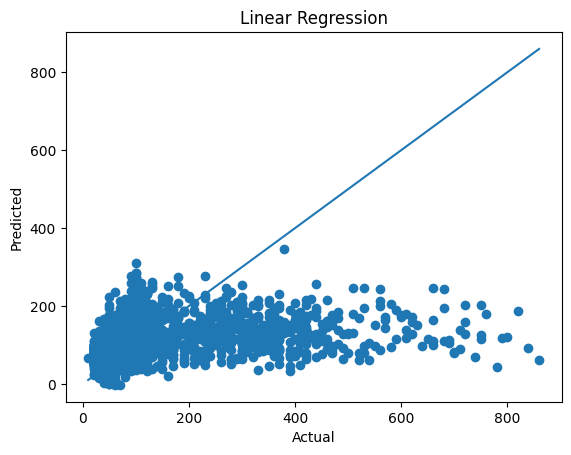

In [ ]:
# linear_regression.py

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

data = pd.read_csv("energydata_complete.csv")
data = data.select_dtypes(include=['number']).dropna()

X = data.drop("Appliances", axis=1)
y = data["Appliances"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, pred))
print("R2:", r2_score(y_test, pred))

# Graph
plt.scatter(y_test, pred)
plt.title("Linear Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.show()

Random Forest
MAE: 33.03709146186977
R2: 0.557266001419064


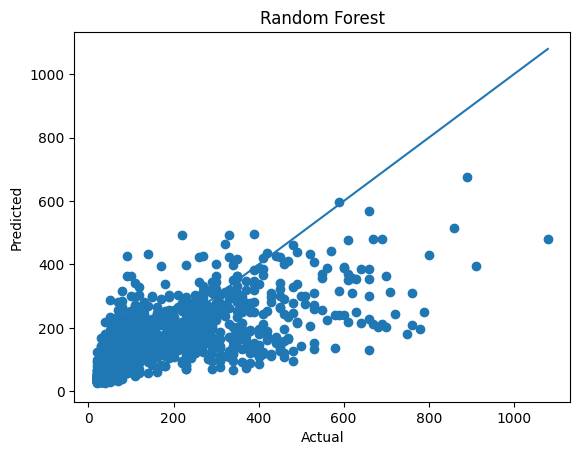

In [ ]:
# random_forest.py

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

data = pd.read_csv("energydata_complete.csv")
data = data.select_dtypes(include=['number']).dropna()

X = data.drop("Appliances", axis=1)
y = data["Appliances"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Random Forest")
print("MAE:", mean_absolute_error(y_test, pred))
print("R2:", r2_score(y_test, pred))

# Graph
plt.scatter(y_test, pred)
plt.title("Random Forest")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression
Accuracy: 0.8021281986318723
Confusion Matrix:
 [[2705  197]
 [ 584  461]]


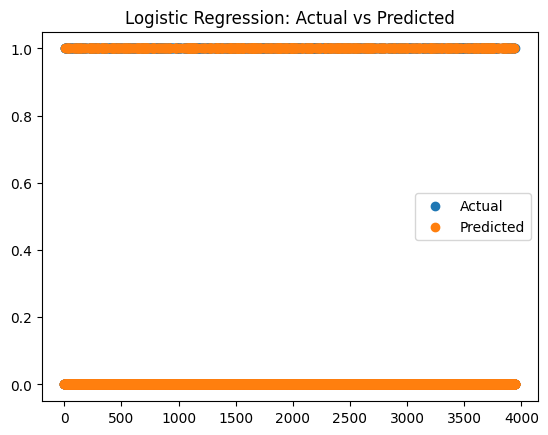

In [ ]:
# logistic_regression.py

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
data = pd.read_csv("energydata_complete.csv")

# Keep only numeric values
data = data.select_dtypes(include=['number']).dropna()

# Convert target into classification (0 or 1)
# 0 = Low energy, 1 = High energy
threshold = data["Appliances"].mean()
data["Appliances"] = (data["Appliances"] > threshold).astype(int)

# Features & Target
X = data.drop("Appliances", axis=1)
y = data["Appliances"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Prediction
pred = model.predict(X_test)

# Metrics
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))

# -------- GRAPH --------
plt.scatter(range(len(y_test)), y_test, label="Actual")
plt.scatter(range(len(pred)), pred, label="Predicted")
plt.legend()
plt.title("Logistic Regression: Actual vs Predicted")
plt.show()

Random Forest is the best model because it gives higher accuracy with lower error.
It reduces overfitting by combining multiple decision trees, so the predictions are more reliable